# Visualisasi Evaluasi RAG

Notebook ini memvisualisasikan hasil evaluasi retrieval dan generasi untuk 3 metode chunking:
- Element-Based
- MaxMin Semantic
- Recursive

**Scope**: Top-5 hingga Top-10


In [1]:
# Cell 1: Setup dan Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Config
TOPK_MIN = 5
TOPK_MAX = 10
DATA_DIR = Path("../results/final/generation")
FIG_DIR = Path("../results/final/figures")
GT_DIR = Path("../data/ground_truth")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load data
dfs = []
for k in range(TOPK_MIN, TOPK_MAX + 1):
    pattern = f"eval_*_top{k}.csv"
    files = list(DATA_DIR.glob(pattern))
    if files:
        df = pd.read_csv(files[0])
        df['top_k'] = k
        dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
qa_gold = pd.read_excel(GT_DIR / "qa_gold_standard_rag_bps_30qa_question_newest.xlsx", sheet_name="qa_gold")
retrieval_labels = pd.read_csv(GT_DIR / "retrieval_labels_final.csv")

# Method name mapping
method_map = {
    'Element-Based': 'Element',
    'MaxMin Semantic': 'MaxMin',
    'Recursive': 'Recursive'
}
data['method_short'] = data['method'].map(method_map)

print(f"Loaded {len(data)} rows (top-{TOPK_MIN} to top-{TOPK_MAX})")
print(f"Methods: {data['method'].unique()}")
print(f"QA gold rows: {len(qa_gold)}")
print(f"Retrieval labels rows: {len(retrieval_labels)}")

Loaded 540 rows (top-5 to top-10)
Methods: <ArrowStringArray>
['Element-Based', 'MaxMin Semantic', 'Recursive']
Length: 3, dtype: str
QA gold rows: 30
Retrieval labels rows: 416


In [2]:
# Cell 2: Agregasi SEMUA data untuk visualisasi + Definisi fungsi highlight

# 1. Trend Precision, Recall & MRR (untuk Chart 1, 2 & 3)
trend = data.groupby(['method_short', 'top_k'])[['precision_at_k', 'recall_at_k', 'mrr']].mean().reset_index()

# 2. Generasi metrik (untuk Chart 5 & 6)
gen_avg = (
    data.groupby(['method_short', 'top_k'])[['bleu', 'rouge_l_recall']]
    .mean()
    .reset_index()
    .rename(columns={'rouge_l_recall': 'rouge_l'})
)

# 3. Hit count (untuk Chart 7)
hit_counts = []
for k in range(TOPK_MIN, TOPK_MAX + 1):
    for method in data['method_short'].unique():
        subset = data[(data['top_k'] == k) & (data['method_short'] == method)]
        n_hit = (subset['mrr'] > 0).sum()
        hit_counts.append({'method': method, 'top_k': k, 'hit_count': n_hit})
hit_df = pd.DataFrame(hit_counts)

# 4. Top-5 data
top5 = data[data['top_k'] == TOPK_MIN].copy()

# 5. Heatmap data (legacy, tidak divisualisasikan dalam urutan chart saat ini)
heatmap_data = top5.pivot_table(
    index='query_id',
    columns='method_short',
    values='mrr',
    aggfunc='mean'
).fillna(0)

# 6. Ground truth summary data (untuk Chart 9 & 10)
qa_evidence_counts = (
    qa_gold['evidence_type']
    .fillna('Unknown')
    .replace('', 'Unknown')
    .value_counts()
    .rename_axis('Evidence Type')
    .reset_index(name='Count')
)

label_counts = (
    retrieval_labels['label']
    .value_counts()
    .sort_index()
    .rename_axis('Label')
    .reset_index(name='Count')
)
label_counts['Label Name'] = label_counts['Label'].map({0: '0 = Tidak Relevan', 1: '1 = Relevan'}).fillna(label_counts['Label'].astype(str))

def highlight_max_only(s):
    """Bold hanya nilai maksimum tanpa memberi background color."""
    is_max = s == s.max()
    return ['font-weight: 700' if v else '' for v in is_max]


def format_metric_table(df, axis=1, fmt='{:.4f}'):
    """Render tabel center-align dan bold-only untuk nilai terbesar."""
    return (
        df.style
        .format(fmt)
        .apply(highlight_max_only, axis=axis)
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'center')]},
        ])
    )


METHOD_LABEL_OFFSETS = {
    'Element': (0, 18),
    'MaxMin': (0, -18),
    'Recursive': (0, 18),
}


def annotate_grouped_line_points(ax, df, x_col, y_col, label_col='method_short', fontsize=9):
    """Tempatkan label menjauh dari garis, terutama saat nilai antar metode berdekatan."""
    close_threshold = 0.018
    close_cluster_offsets = [(0, 18), (0, -18), (0, 30)]
    label_positions = {}

    for _, group in df.groupby(x_col):
        sorted_group = group.sort_values(y_col, ascending=False).reset_index().rename(columns={'index': '_row_id'})
        used = set()
        for idx, row in sorted_group.iterrows():
            if idx in used:
                continue
            cluster = [idx]
            used.add(idx)
            for next_idx in range(idx + 1, len(sorted_group)):
                if abs(row[y_col] - sorted_group.loc[next_idx, y_col]) <= close_threshold:
                    cluster.append(next_idx)
                    used.add(next_idx)

            if len(cluster) == 1:
                cluster_row = sorted_group.loc[cluster[0]]
                label_positions[cluster_row['_row_id'], cluster_row[label_col], cluster_row[x_col]] = METHOD_LABEL_OFFSETS.get(
                    cluster_row[label_col], (0, 14)
                )
            else:
                for offset_idx, cluster_idx in enumerate(cluster):
                    cluster_row = sorted_group.loc[cluster_idx]
                    label_positions[cluster_row['_row_id'], cluster_row[label_col], cluster_row[x_col]] = close_cluster_offsets[
                        min(offset_idx, len(close_cluster_offsets) - 1)
                    ]

    for _, row in df.iterrows():
        x_offset, y_offset = label_positions.get(
            (row.name, row[label_col], row[x_col]),
            METHOD_LABEL_OFFSETS.get(row[label_col], (0, 14))
        )
        valign = 'bottom' if y_offset >= 0 else 'top'
        ax.annotate(
            f"{row[y_col]:.3f}",
            (row[x_col], row[y_col]),
            textcoords='offset points',
            xytext=(x_offset, y_offset),
            ha='center',
            va=valign,
            fontsize=fontsize,
            color='#374151',
            bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.78)
        )


def pad_y_axis(ax, values, pad_ratio=0.18):
    """Tambah ruang vertikal agar label tidak kepotong di tepi chart."""
    y_min = float(values.min())
    y_max = float(values.max())
    span = y_max - y_min
    pad = max(span * pad_ratio, 0.015)
    ax.set_ylim(y_min - pad, y_max + pad)

print('Agregasi data selesai:')
print(f"  - trend: {len(trend)} rows")
print(f"  - gen_avg: {len(gen_avg)} rows")
print(f"  - hit_df: {len(hit_df)} rows")
print(f"  - top5: {len(top5)} rows")
print(f"  - heatmap_data: {heatmap_data.shape}")
print(f"  - qa_evidence_counts: {len(qa_evidence_counts)} rows")
print(f"  - label_counts: {len(label_counts)} rows")

Agregasi data selesai:
  - trend: 18 rows
  - gen_avg: 18 rows
  - hit_df: 18 rows
  - top5: 90 rows
  - heatmap_data: (30, 3)
  - qa_evidence_counts: 4 rows
  - label_counts: 2 rows


## Chart 1: Trend Precision@k vs Top-k

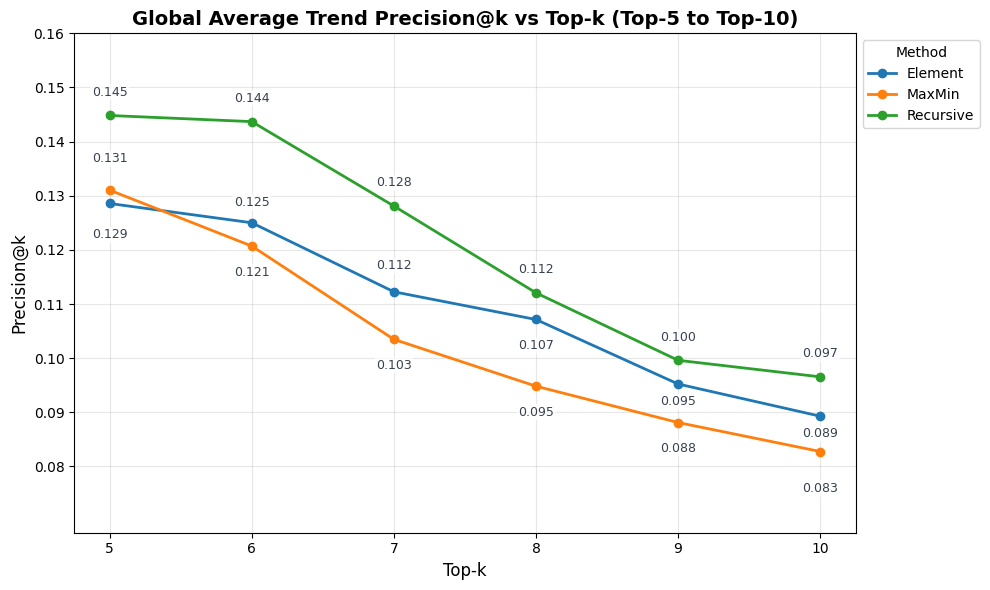

Chart 1 saved

Tabel 1: Precision@k per Metode dan Top-k


Method,Element,MaxMin,Recursive
Top-k,,,
5,0.1286,0.1310,0.1448
6,0.1250,0.1207,0.1437
7,0.1123,0.1035,0.1281
8,0.1071,0.0948,0.1121
9,0.0952,0.0881,0.0996
10,0.0893,0.0828,0.0966


Table 1 exported


In [3]:
# Chart 1 + Tabel 1: Precision trend (DALAM SATU CELL)

# === CHART ===
fig, ax = plt.subplots(figsize=(10, 6))
for method in trend['method_short'].unique():
    subset = trend[trend['method_short'] == method]
    ax.plot(subset['top_k'], subset['precision_at_k'], marker='o', label=method, linewidth=2)

precision_label_offsets = {
    ('Element', 5): (0, -18),
    ('MaxMin', 5): (0, 18),
    ('MaxMin', 6): (0, -14),
    ('MaxMin', 7): (0, -14),
    ('Element', 7): (0, 14),
    ('Element', 8): (0, -14),
    ('Element', 9): (0, -8),
    ('Element', 10): (0, -8),
    ('MaxMin', 8): (0, -14),
    ('MaxMin', 9): (0, -14),
    ('MaxMin', 10): (0, -22),
}
precision_default_offsets = {
    'Element': (0, 10),
    'MaxMin': (0, 10),
    'Recursive': (0, 12),
}
for _, row in trend.iterrows():
    x_offset, y_offset = precision_label_offsets.get(
        (row['method_short'], int(row['top_k'])),
        precision_default_offsets[row['method_short']]
    )
    ax.annotate(
        f"{row['precision_at_k']:.3f}",
        (row['top_k'], row['precision_at_k']),
        textcoords='offset points',
        xytext=(x_offset, y_offset),
        ha='center',
        va='bottom' if y_offset >= 0 else 'top',
        fontsize=9,
        color='#374151',
        bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.78)
    )

ax.set_xlabel('Top-k', fontsize=12)
ax.set_ylabel('Precision@k', fontsize=12)
ax.set_title('Global Average Trend Precision@k vs Top-k (Top-5 to Top-10)', fontsize=14, fontweight='bold')
ax.legend(title='Method', fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(alpha=0.3)
ax.set_xticks(range(TOPK_MIN, TOPK_MAX + 1))
pad_y_axis(ax, trend['precision_at_k'])
precision_y_top = np.ceil(ax.get_ylim()[1] * 100) / 100
precision_yticks = np.round(np.arange(0.08, precision_y_top + 0.001, 0.01), 2)
ax.set_yticks(precision_yticks)
ax.set_yticklabels([f'{tick:.2f}' for tick in precision_yticks])

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart1_precision_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart 1 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table1 = (
    trend.pivot(index='top_k', columns='method_short', values='precision_at_k')
    .rename_axis(index='Top-k', columns='Method')
)
print('\nTabel 1: Precision@k per Metode dan Top-k')
styled_table1 = format_metric_table(table1, axis=1)
display(styled_table1)

# Export CSV
table1.to_csv(FIG_DIR / 'table1_precision_trend.csv')
print('Table 1 exported')

## Chart 2: Trend Recall@k vs Top-k

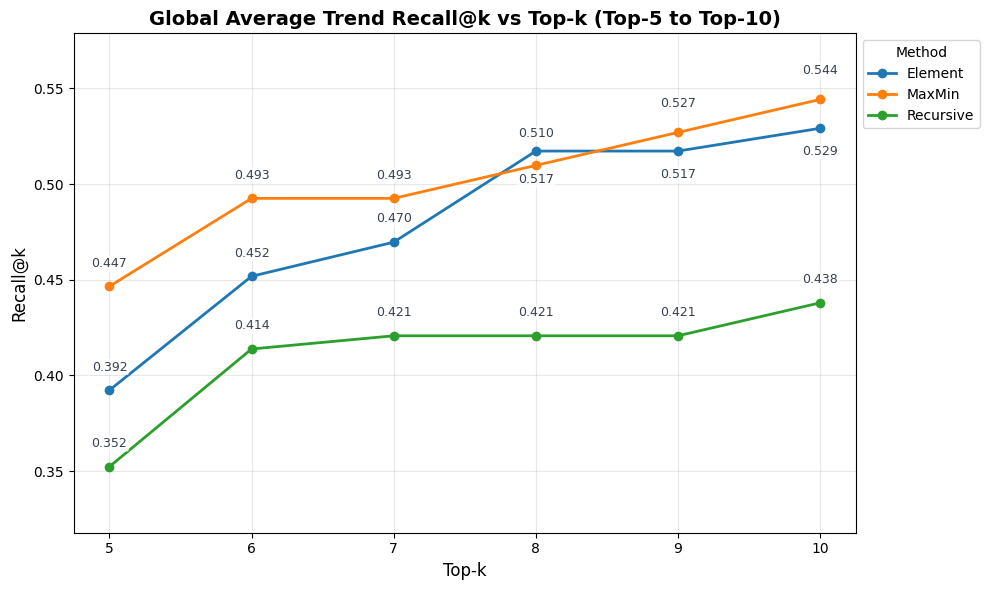

Chart 2 saved

Tabel 2: Recall@k per Metode dan Top-k


Method,Element,MaxMin,Recursive
Top-k,,,
5,0.3923,0.4466,0.3523
6,0.4518,0.4925,0.4138
7,0.4696,0.4925,0.4207
8,0.5173,0.5098,0.4207
9,0.5173,0.5270,0.4207
10,0.5292,0.5443,0.4379


Table 2 exported


In [4]:
# Chart 2 + Tabel 2: Recall trend (DALAM SATU CELL)

# === CHART ===
fig, ax = plt.subplots(figsize=(10, 6))
for method in trend['method_short'].unique():
    subset = trend[trend['method_short'] == method]
    ax.plot(subset['top_k'], subset['recall_at_k'], marker='o', label=method, linewidth=2)

recall_late_offsets = {
    'Element': (0, -12),
    'MaxMin': (0, 16),
    'Recursive': (0, 12),
}
for _, row in trend.iterrows():
    x_offset, y_offset = (0, 12) if row['top_k'] < 8 else recall_late_offsets[row['method_short']]
    if row['top_k'] == 8 and row['method_short'] == 'Element':
        y_offset = -16
    elif row['top_k'] == 8 and row['method_short'] == 'MaxMin':
        y_offset = 18
    ax.annotate(
        f"{row['recall_at_k']:.3f}",
        (row['top_k'], row['recall_at_k']),
        textcoords='offset points',
        xytext=(x_offset, y_offset),
        ha='center',
        va='bottom' if y_offset >= 0 else 'top',
        fontsize=9,
        color='#374151',
        bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.78)
    )

ax.set_xlabel('Top-k', fontsize=12)
ax.set_ylabel('Recall@k', fontsize=12)
ax.set_title('Global Average Trend Recall@k vs Top-k (Top-5 to Top-10)', fontsize=14, fontweight='bold')
ax.legend(title='Method', fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(alpha=0.3)
ax.set_xticks(range(TOPK_MIN, TOPK_MAX + 1))
pad_y_axis(ax, trend['recall_at_k'])

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart2_recall_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart 2 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table2 = (
    trend.pivot(index='top_k', columns='method_short', values='recall_at_k')
    .rename_axis(index='Top-k', columns='Method')
)
print('\nTabel 2: Recall@k per Metode dan Top-k')
styled_table2 = format_metric_table(table2, axis=1)
display(styled_table2)

# Export CSV
table2.to_csv(FIG_DIR / 'table2_recall_trend.csv')
print('Table 2 exported')

## Chart 3: Trend MRR vs Top-k

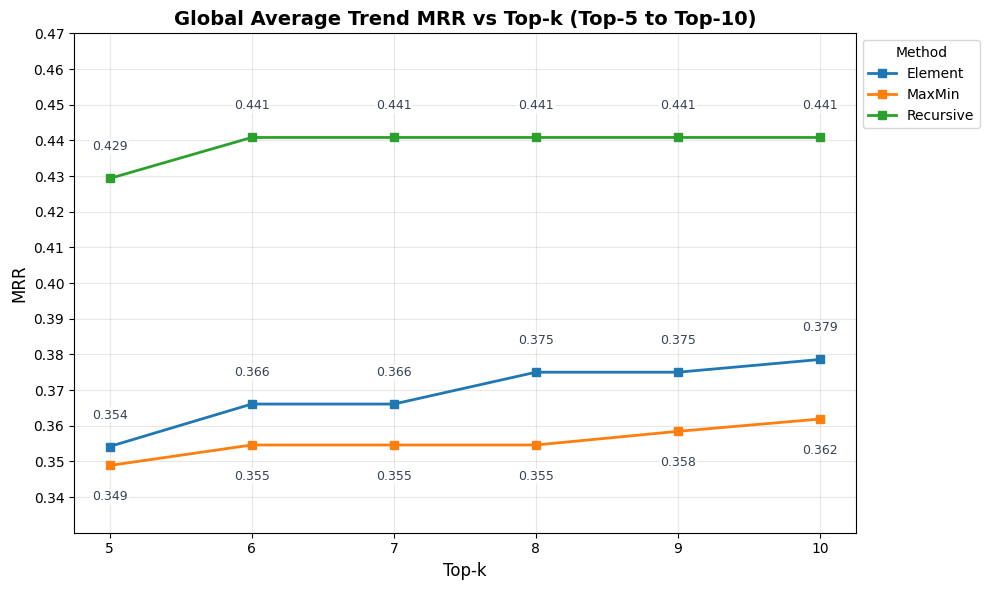

Chart 3 saved

Tabel 3: Global Average MRR per Metode dan Top-k


Method,Element,MaxMin,Recursive
Top-k,,,
5,0.3542,0.3488,0.4293
6,0.3661,0.3546,0.4408
7,0.3661,0.3546,0.4408
8,0.3750,0.3546,0.4408
9,0.3750,0.3584,0.4408
10,0.3786,0.3619,0.4408


Table 3 exported


In [5]:
# Chart 3 + Tabel 3: MRR trend (DALAM SATU CELL)

# === CHART ===
fig, ax = plt.subplots(figsize=(10, 6))
for method in trend['method_short'].unique():
    subset = trend[trend['method_short'] == method]
    ax.plot(subset['top_k'], subset['mrr'], marker='s', label=method, linewidth=2)
annotate_grouped_line_points(ax, trend, 'top_k', 'mrr')

ax.set_xlabel('Top-k', fontsize=12)
ax.set_ylabel('MRR', fontsize=12)
ax.set_title('Global Average Trend MRR vs Top-k (Top-5 to Top-10)', fontsize=14, fontweight='bold')
ax.legend(title='Method', fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(alpha=0.3)
ax.set_xticks(range(TOPK_MIN, TOPK_MAX + 1))
mrr_y_top = np.ceil((trend['mrr'].max() + 0.025) * 100) / 100
mrr_yticks = np.round(np.arange(0.34, mrr_y_top + 0.001, 0.01), 2)
ax.set_ylim(0.33, mrr_y_top)
ax.set_yticks(mrr_yticks)
ax.set_yticklabels([f'{tick:.2f}' for tick in mrr_yticks])

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart3_mrr_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart 3 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table3 = (
    trend.pivot(index='top_k', columns='method_short', values='mrr')
    .rename_axis(index='Top-k', columns='Method')
)
print('\nTabel 3: Global Average MRR per Metode dan Top-k')
styled_table3 = format_metric_table(table3, axis=1)
display(styled_table3)

# Export CSV
table3.to_csv(FIG_DIR / 'table3_mrr_trend.csv')
print('Table 3 exported')

## Chart 4: Distribusi Posisi Chunk Relevan Pertama MRR

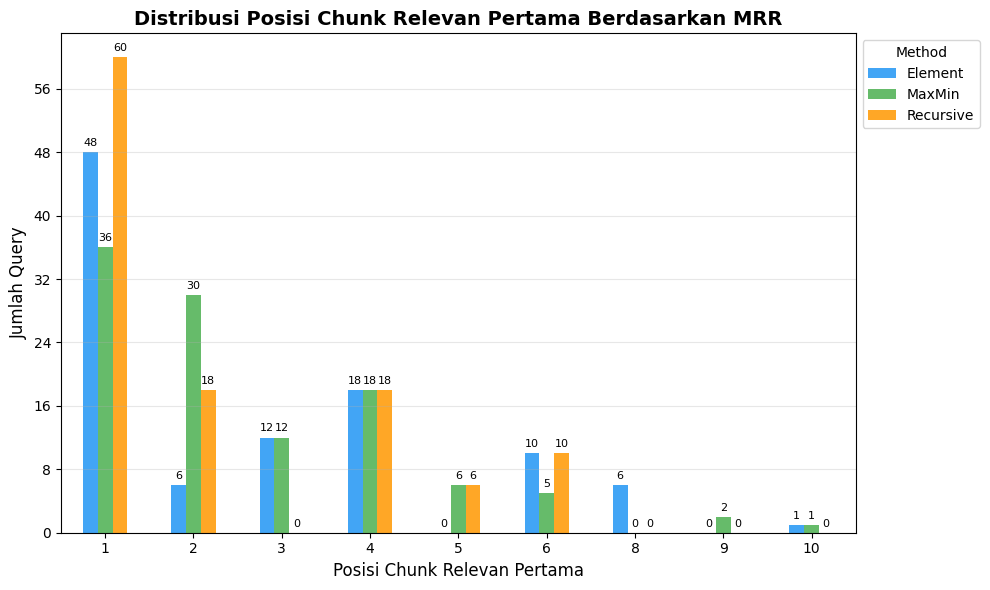

Chart 4 saved

Tabel 4: Distribusi Posisi Chunk Relevan Pertama Berdasarkan MRR


Method,Element,MaxMin,Recursive
Posisi Chunk Relevan Pertama,,,
1,48,36,60
2,6,30,18
3,12,12,0
4,18,18,18
5,0,6,6
6,10,5,10
8,6,0,0
9,0,2,0
10,1,1,0


Table 4 exported


In [6]:
# Chart 4 + Tabel 4: Distribusi posisi chunk relevan pertama berdasarkan MRR

# === CHART ===
from matplotlib.ticker import MaxNLocator

mrr_position_data = data[data['mrr'] > 0].copy()
mrr_position_data['first_relevant_position'] = (1 / mrr_position_data['mrr']).round().astype(int)
position_counts = (
    mrr_position_data
    .groupby(['method_short', 'first_relevant_position'])
    .size()
    .reset_index(name='count')
)
position_pivot = (
    position_counts
    .pivot(index='first_relevant_position', columns='method_short', values='count')
    .fillna(0)
    .astype(int)
    .sort_index()
    .rename_axis(index='Posisi Chunk Relevan Pertama', columns='Method')
)

position_pivot.plot(kind='bar', figsize=(10, 6), color=['#42a5f5', '#66bb6a', '#ffa726'])

plt.xlabel('Posisi Chunk Relevan Pertama', fontsize=12)
plt.ylabel('Jumlah Query', fontsize=12)
plt.title('Distribusi Posisi Chunk Relevan Pertama Berdasarkan MRR', fontsize=14, fontweight='bold')
plt.legend(title='Method', fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

plt.grid(axis='y', alpha=0.3)
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%d', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart4_mrr_first_relevant_position.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart 4 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table4 = position_pivot
print('\nTabel 4: Distribusi Posisi Chunk Relevan Pertama Berdasarkan MRR')
styled_table4 = format_metric_table(table4, axis=1, fmt='{:.0f}')
display(styled_table4)

# Export CSV
table4.to_csv(FIG_DIR / 'table4_mrr_first_relevant_position.csv')
print('Table 4 exported')

## Chart 5: BLEU per Metode dan Top-k (Top-5 hingga Top-10)

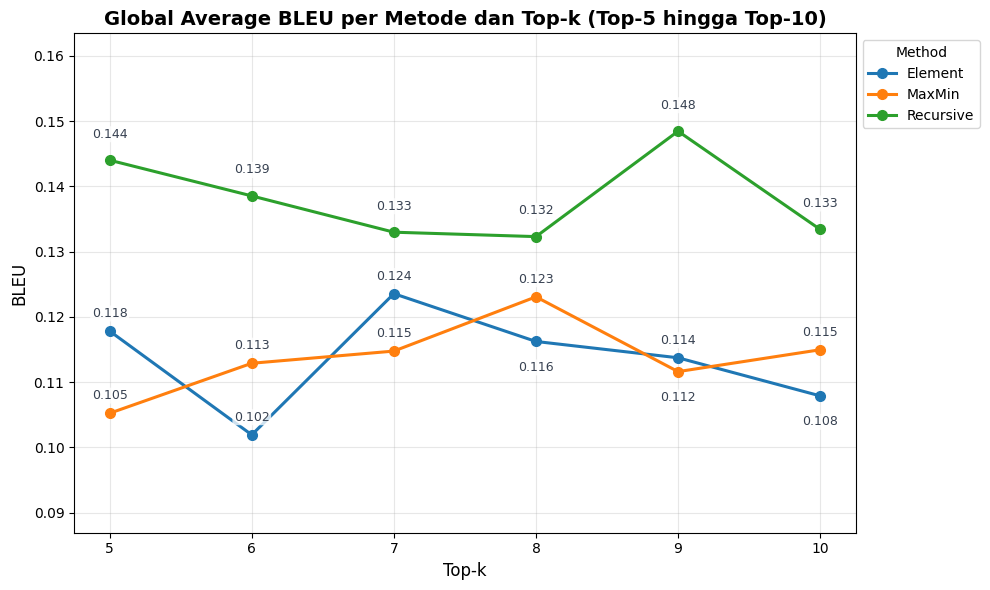

Chart 5 saved

Tabel 5: Global Average BLEU per Metode dan Top-k (Top-5 hingga Top-10)


Method,Element,MaxMin,Recursive
Top-k,,,
5,0.1178,0.1052,0.1440
6,0.1019,0.1129,0.1385
7,0.1236,0.1148,0.1330
8,0.1162,0.1231,0.1323
9,0.1137,0.1116,0.1485
10,0.1079,0.1150,0.1334


Table 5 exported


In [7]:
# Chart 5 + Tabel 5: BLEU per Top-k (DALAM SATU CELL)

# === CHART ===
fig, ax = plt.subplots(figsize=(10, 6))
color_map = {'Element': '#1f77b4', 'MaxMin': '#ff7f0e', 'Recursive': '#2ca02c'}
bleu_label_offsets = {
    ('MaxMin', 9): (0, -14),
    ('Element', 8): (0, -14),
    ('Element', 10): (0, -14),
}
recursive_label_offset = (0, 14)

for method in ['Element', 'MaxMin', 'Recursive']:
    subset = gen_avg[gen_avg['method_short'] == method].sort_values('top_k')
    ax.plot(
        subset['top_k'],
        subset['bleu'],
        marker='o',
        linewidth=2.2,
        markersize=7,
        label=method,
        color=color_map[method]
    )
    for _, row in subset.iterrows():
        x_offset, y_offset = bleu_label_offsets.get((method, int(row['top_k'])), recursive_label_offset if method == 'Recursive' else (0, 8))
        valign = 'bottom' if y_offset >= 0 else 'top'
        ax.annotate(
            f"{row['bleu']:.3f}",
            (row['top_k'], row['bleu']),
            textcoords='offset points',
            xytext=(x_offset, y_offset),
            ha='center',
            va=valign,
            fontsize=9,
            color='#374151',
            bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.78)
        )

ax.set_xlabel('Top-k', fontsize=12)
ax.set_ylabel('BLEU', fontsize=12)
ax.set_title(f'Global Average BLEU per Metode dan Top-k (Top-{TOPK_MIN} hingga Top-{TOPK_MAX})', fontsize=14, fontweight='bold')
ax.set_xticks(list(range(TOPK_MIN, TOPK_MAX + 1)))
ax.legend(title='Method', fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='both', alpha=0.3)
pad_y_axis(ax, gen_avg['bleu'])

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart5_bleu_topk.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart 5 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table5 = (
    gen_avg.pivot(index='top_k', columns='method_short', values='bleu')
    .rename_axis(index='Top-k', columns='Method')
)
print()
print(f'Tabel 5: Global Average BLEU per Metode dan Top-k (Top-{TOPK_MIN} hingga Top-{TOPK_MAX})')
styled_table5 = format_metric_table(table5, axis=1)
display(styled_table5)

# Export CSV
table5.to_csv(FIG_DIR / 'table5_bleu_topk.csv')
print('Table 5 exported')

## Chart 6: ROUGE-L per Metode dan Top-k (Top-5 hingga Top-10)

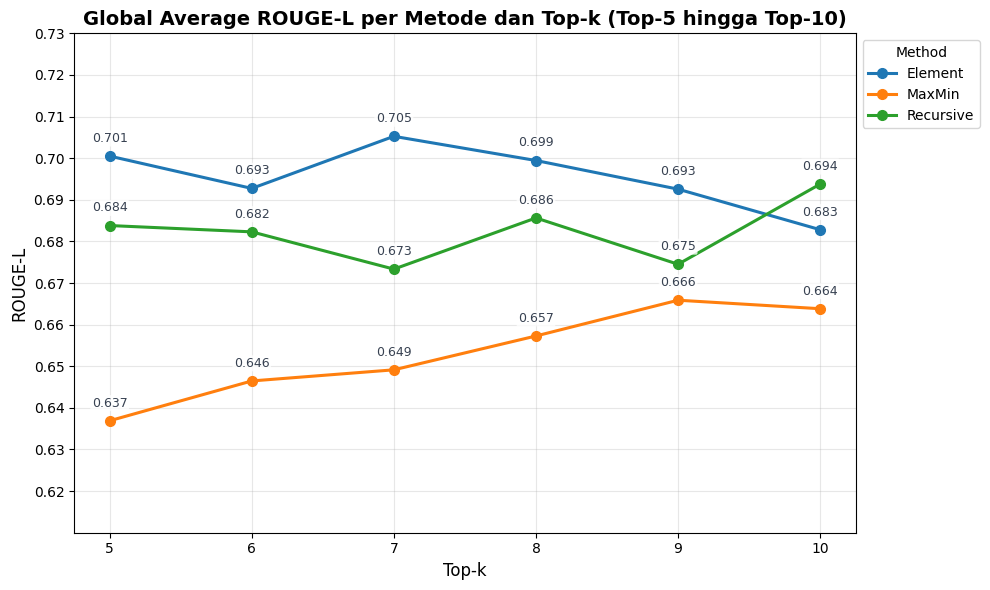

Chart 6 saved

Tabel 6: Global Average ROUGE-L per Metode dan Top-k (Top-5 hingga Top-10)


Method,Element,MaxMin,Recursive
Top-k,,,
5,0.7005,0.6369,0.6838
6,0.6927,0.6465,0.6823
7,0.7053,0.6491,0.6733
8,0.6994,0.6573,0.6856
9,0.6926,0.6659,0.6745
10,0.6828,0.6638,0.6938


Table 6 exported


In [8]:
# Chart 6 + Tabel 6: ROUGE-L per Top-k (DALAM SATU CELL)

# === CHART ===
fig, ax = plt.subplots(figsize=(10, 6))
color_map = {'Element': '#1f77b4', 'MaxMin': '#ff7f0e', 'Recursive': '#2ca02c'}

for method in ['Element', 'MaxMin', 'Recursive']:
    subset = gen_avg[gen_avg['method_short'] == method].sort_values('top_k')
    ax.plot(
        subset['top_k'],
        subset['rouge_l'],
        marker='o',
        linewidth=2.2,
        markersize=7,
        label=method,
        color=color_map[method]
    )
    for _, row in subset.iterrows():
        ax.annotate(
            f"{row['rouge_l']:.3f}",
            (row['top_k'], row['rouge_l']),
            textcoords='offset points',
            xytext=(0, 8),
            ha='center',
            va='bottom',
            fontsize=9,
            color='#374151',
            bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.78)
        )

ax.set_xlabel('Top-k', fontsize=12)
ax.set_ylabel('ROUGE-L', fontsize=12)
ax.set_title(f'Global Average ROUGE-L per Metode dan Top-k (Top-{TOPK_MIN} hingga Top-{TOPK_MAX})', fontsize=14, fontweight='bold')
ax.set_xticks(list(range(TOPK_MIN, TOPK_MAX + 1)))
ax.legend(title='Method', fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='both', alpha=0.3)
rouge_y_bottom = np.floor((gen_avg['rouge_l'].min() - 0.02) * 100) / 100
rouge_y_top = np.ceil((gen_avg['rouge_l'].max() + 0.02) * 100) / 100
rouge_yticks = np.round(np.arange(rouge_y_bottom + 0.01, rouge_y_top + 0.001, 0.01), 2)
ax.set_ylim(rouge_y_bottom, rouge_y_top)
ax.set_yticks(rouge_yticks)
ax.set_yticklabels([f'{tick:.2f}' for tick in rouge_yticks])

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart6_rouge_l_topk.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart 6 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table6 = (
    gen_avg.pivot(index='top_k', columns='method_short', values='rouge_l')
    .rename_axis(index='Top-k', columns='Method')
)
print()
print(f'Tabel 6: Global Average ROUGE-L per Metode dan Top-k (Top-{TOPK_MIN} hingga Top-{TOPK_MAX})')
styled_table6 = format_metric_table(table6, axis=1)
display(styled_table6)

# Export CSV
table6.to_csv(FIG_DIR / 'table6_rouge_l_topk.csv')
print('Table 6 exported')

## Chart 7: Jumlah Query Berhasil (MRR > 0) per Top-k

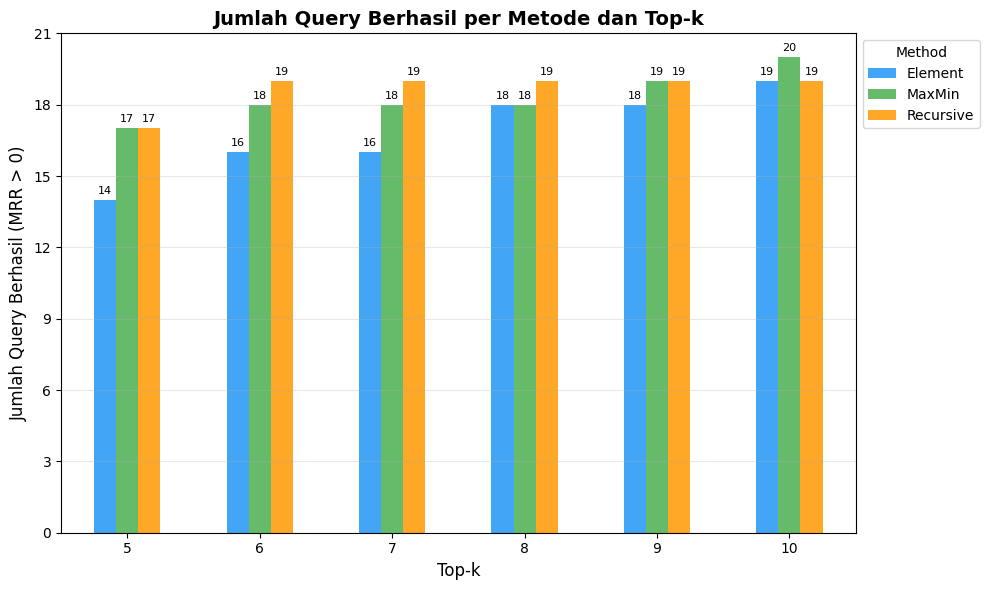

Chart 7 saved

Tabel 7: Jumlah Query Berhasil (MRR > 0) per Top-k


Method,Element,MaxMin,Recursive
Top-k,,,
5,14,17,17
6,16,18,19
7,16,18,19
8,18,18,19
9,18,19,19
10,19,20,19


Table 7 exported


In [9]:
# Chart 7 + Tabel 7: Hit count (DALAM SATU CELL)

# === CHART ===
pivot_hit = hit_df.pivot(index='top_k', columns='method', values='hit_count')
pivot_hit.plot(kind='bar', figsize=(10, 6), color=['#42a5f5', '#66bb6a', '#ffa726'])

plt.xlabel('Top-k', fontsize=12)
plt.ylabel('Jumlah Query Berhasil (MRR > 0)', fontsize=12)
plt.title('Jumlah Query Berhasil per Metode dan Top-k', fontsize=14, fontweight='bold')
plt.legend(title='Method', fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
# Format Y-axis sebagai integer (bukan float)
from matplotlib.ticker import MaxNLocator
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

plt.grid(axis='y', alpha=0.3)
# Annotate values at top of each bar
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%d', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart7_hit_count.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart 7 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table7 = pivot_hit.rename_axis(index='Top-k', columns='Method')
print('\nTabel 7: Jumlah Query Berhasil (MRR > 0) per Top-k')
styled_table7 = format_metric_table(table7, axis=1, fmt='{:.0f}')
display(styled_table7)

# Export CSV
table7.to_csv(FIG_DIR / 'table7_hit_count.csv')
print('Table 7 exported')

## Chart 8: Jumlah Query Gagal (MRR = 0) per Top-k

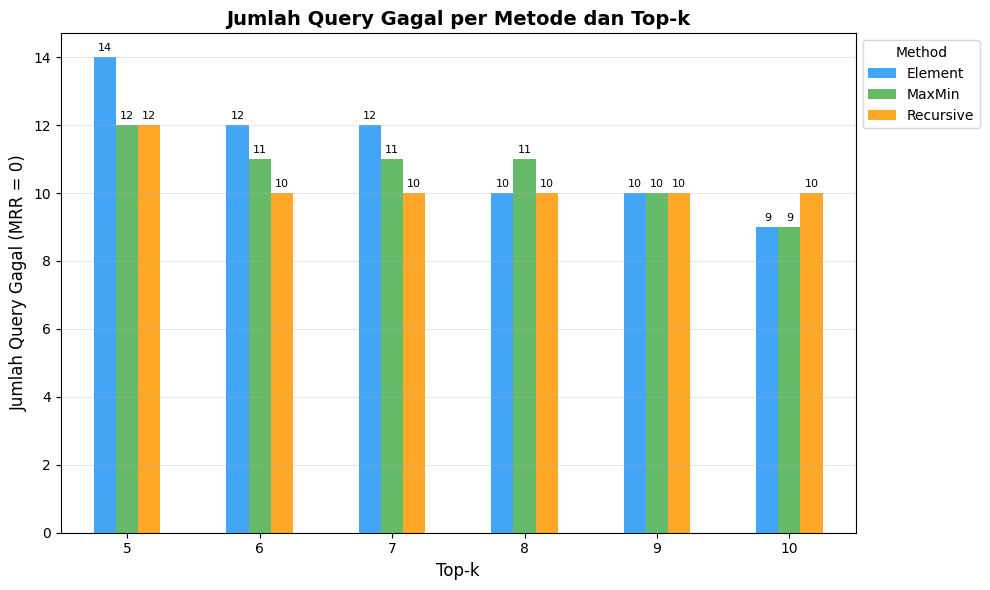

Chart 8 saved

Tabel 8: Jumlah Query Gagal (MRR = 0) per Top-k


Method,Element,MaxMin,Recursive
Top-k,,,
5,14,12,12
6,12,11,10
7,12,11,10
8,10,11,10
9,10,10,10
10,9,9,10


Table 8 exported


In [10]:
# Chart 8 + Tabel 8: Gagal count (DALAM SATU CELL)

# === CHART ===
fail_counts = []
for k in range(TOPK_MIN, TOPK_MAX + 1):
    for method in data['method_short'].unique():
        subset = data[(data['top_k'] == k) & (data['method_short'] == method)]
        n_fail = (subset['mrr'] == 0).sum()
        fail_counts.append({'method': method, 'top_k': k, 'fail_count': n_fail})
fail_df = pd.DataFrame(fail_counts)

pivot_fail = fail_df.pivot(index='top_k', columns='method', values='fail_count')
pivot_fail.plot(kind='bar', figsize=(10, 6), color=['#42a5f5', '#66bb6a', '#ffa726'])

plt.xlabel('Top-k', fontsize=12)
plt.ylabel('Jumlah Query Gagal (MRR = 0)', fontsize=12)
plt.title('Jumlah Query Gagal per Metode dan Top-k', fontsize=14, fontweight='bold')
plt.legend(title='Method', fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

plt.grid(axis='y', alpha=0.3)
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%d', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart8_fail_count.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart 8 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table8 = pivot_fail.rename_axis(index='Top-k', columns='Method')
print('\nTabel 8: Jumlah Query Gagal (MRR = 0) per Top-k')
styled_table8 = format_metric_table(table8, axis=1, fmt='{:.0f}')
display(styled_table8)

# Export CSV
table8.to_csv(FIG_DIR / 'table8_fail_count.csv')
print('Table 8 exported')

## Chart 9: Distribusi Tipe Evidence pada Ground Truth

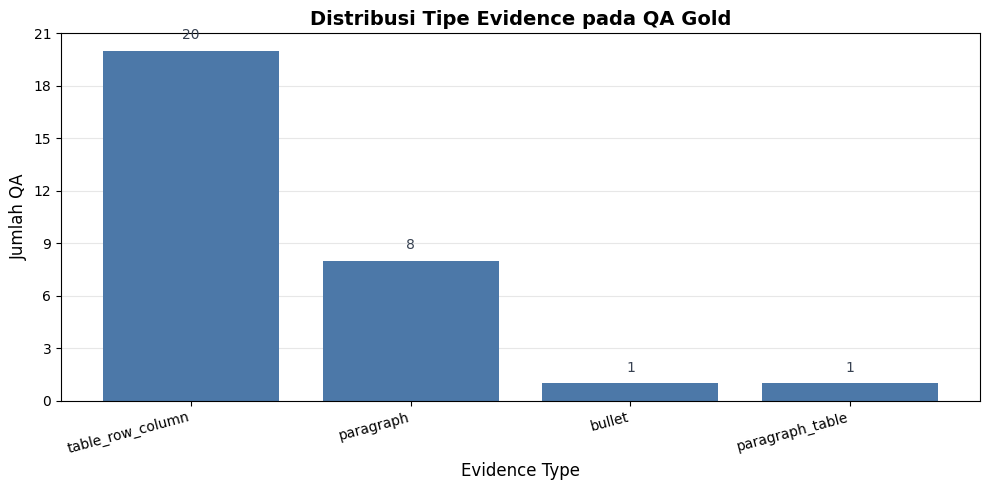

Chart 9 saved

Tabel 9: Distribusi Tipe Evidence pada QA Gold


Evidence Type,Count
table_row_column,20
paragraph,8
bullet,1
paragraph_table,1


Table 9 exported


In [11]:
# Chart 9 + Tabel 9: Distribusi tipe evidence pada QA gold

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(qa_evidence_counts['Evidence Type'], qa_evidence_counts['Count'], color='#4c78a8')

ax.set_xlabel('Evidence Type', fontsize=12)
ax.set_ylabel('Jumlah QA', fontsize=12)
ax.set_title('Distribusi Tipe Evidence pada QA Gold', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.xticks(rotation=15, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        textcoords='offset points',
        xytext=(0, 6),
        ha='center',
        va='bottom',
        fontsize=10,
        color='#374151'
    )

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart9_ground_truth_evidence_types.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart 9 saved')

table9 = qa_evidence_counts.set_index('Evidence Type')
print('\nTabel 9: Distribusi Tipe Evidence pada QA Gold')
table9_display = table9.reset_index()
styled_table9 = (
    table9_display.style
    .format({'Count': '{:.0f}'})
    .apply(highlight_max_only, subset=['Count'], axis=0)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
    ])
    .hide(axis='index')
)
display(styled_table9)
table9.to_csv(FIG_DIR / 'table9_ground_truth_evidence_types.csv')
print('Table 9 exported')

## Chart 10: Distribusi Label Relevansi Ground Truth Retrieval

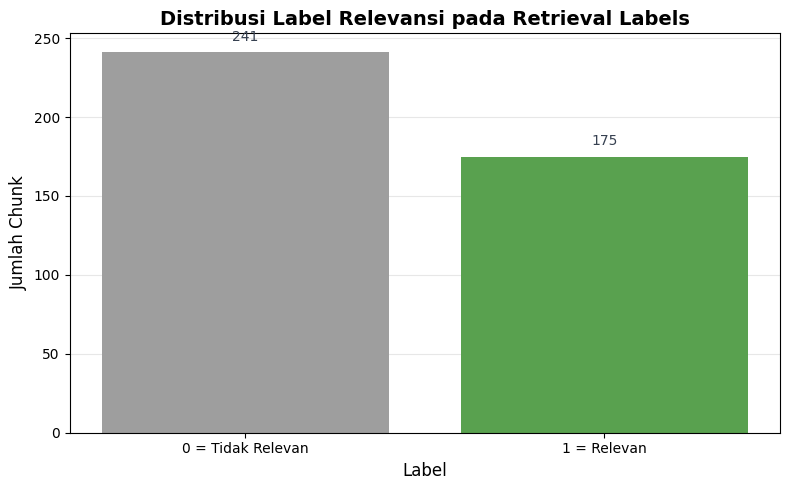

Chart 10 saved

Tabel 10: Distribusi Label Relevansi Retrieval


Label,Count
0 = Tidak Relevan,241
1 = Relevan,175


Table 10 exported


In [12]:
# Chart 10 + Tabel 10: Distribusi label relevansi retrieval labels

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(label_counts['Label Name'], label_counts['Count'], color=['#9e9e9e', '#59a14f'][:len(label_counts)])

ax.set_xlabel('Label', fontsize=12)
ax.set_ylabel('Jumlah Chunk', fontsize=12)
ax.set_title('Distribusi Label Relevansi pada Retrieval Labels', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        textcoords='offset points',
        xytext=(0, 6),
        ha='center',
        va='bottom',
        fontsize=10,
        color='#374151'
    )

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart10_ground_truth_label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart 10 saved')

table10 = label_counts[['Label Name', 'Count']].rename(columns={'Label Name': 'Label'}).set_index('Label')
print('\nTabel 10: Distribusi Label Relevansi Retrieval')
table10_display = table10.reset_index()
styled_table10 = (
    table10_display.style
    .format({'Count': '{:.0f}'})
    .apply(highlight_max_only, subset=['Count'], axis=0)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
    ])
    .hide(axis='index')
)
display(styled_table10)
table10.to_csv(FIG_DIR / 'table10_ground_truth_label_distribution.csv')
print('Table 10 exported')

## Summary

Semua visualisasi dan tabel telah di-generate dan disimpan di `results/final/figures/`:
- **5 Chart PNG** (resolusi 300 DPI untuk laporan)
- **4 Tabel CSV** (untuk analisis numerik lanjutan)

Visualisasi mencakup top-5 hingga top-10 sesuai request user.

**Catatan**:
- Chart dan tabel berada dalam satu cell (tabel tepat di bawah chart)
- Radar chart dihapus sesuai request user
- Tabel styling: highlight HANYA nilai max dengan warna subtle (#d4edda) + bold
- Heatmap: lebih rapi, border putih, annotations readable